# Figure 2: Chromatin vs Gene Expression

**Goal:**
Compute chromatin metrics for each gene and show relationship with gene expression.

**Procedure**
1. Compute: +1 nucleosome shift, gene body entropy, promoter occupancy.
2. Compute PTRs for each and compare to gene expression PTR
3. Compute thresholds to select genes with chromatin and gene expression changes.
4. Show examples of each.
(5). Plot the time course of some of these genes with the arrow plot.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [367]:
from src.Figure3_chromatin_metrics import Figure3ChromatinMetrics

figure3 = Figure3ChromatinMetrics()

Shape of the loaded F: (178, 340)
Shape of the adjusted F shape: (178, 374)
1/5578 - 00:00:00.440
1001/5578 - 00:00:26.290
2001/5578 - 00:00:49.804
3001/5578 - 00:01:13.783
4001/5578 - 00:01:38.434
5001/5578 - 00:01:56.704


In [390]:
figure3.track_img('CLB5')

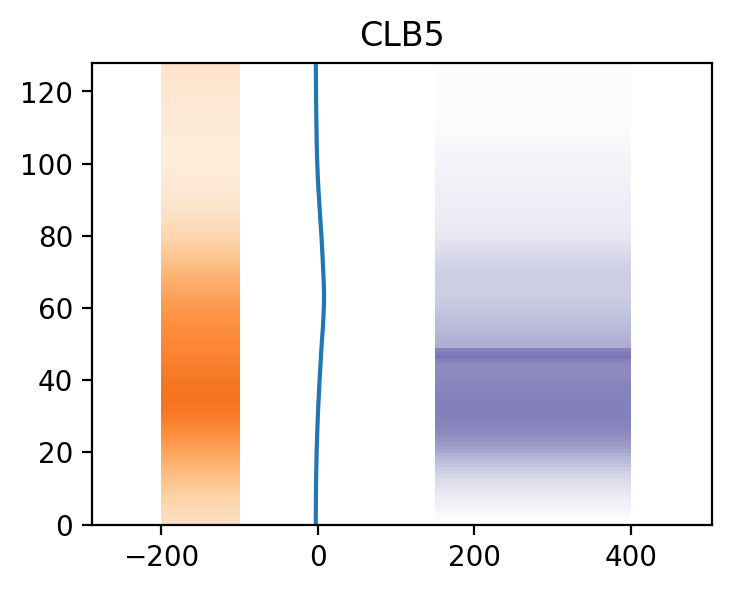

In [393]:
figure3.plot_tracking()

In [ ]:
from src.deconv_data import load_gene_expression_fs
gene_expression_f = load_gene_expression_fs('output/deconvolve_sharedg1_0066_cc_2024_06_13/gene_expression/')

In [418]:
from src.timer import Timer

timer = Timer()

all_df = pd.DataFrame()
i = 0
for orf_name, gene in figure3.genes.iterrows():

    current_gene_expression = gene_expression_f.loc[orf_name]
        
    figure3.track_img(orf_name)
    current_df = figure3.tracking_df.reset_index()
    current_df['orf_name'] = figure3.gene.name
    current_df['gene_expression'] = current_gene_expression
    
    all_df = pd.concat([all_df, current_df])

    if i % 100 == 0:
        timer.print_time(f"{i}/{len(figure3.genes)}")

    i += 1


0/5578 - 00:00:00.045
100/5578 - 00:00:05.805
200/5578 - 00:00:10.870
300/5578 - 00:00:15.756
400/5578 - 00:00:20.548
500/5578 - 00:00:25.547
600/5578 - 00:00:30.571
700/5578 - 00:00:35.555
800/5578 - 00:00:40.399
900/5578 - 00:00:45.464
1000/5578 - 00:00:50.677
1100/5578 - 00:00:56.110
1200/5578 - 00:01:01.310
1300/5578 - 00:01:06.460
1400/5578 - 00:01:11.589
1500/5578 - 00:01:16.766
1600/5578 - 00:01:21.827
1700/5578 - 00:01:27.475
1800/5578 - 00:01:32.814
1900/5578 - 00:01:38.312
2000/5578 - 00:01:43.701
2100/5578 - 00:01:49.457
2200/5578 - 00:01:55.109
2300/5578 - 00:02:00.947
2400/5578 - 00:02:06.261
2500/5578 - 00:02:11.770
2600/5578 - 00:02:17.197
2700/5578 - 00:02:22.672
2800/5578 - 00:02:28.164
2900/5578 - 00:02:33.844
3000/5578 - 00:02:39.461
3100/5578 - 00:02:45.176
3200/5578 - 00:02:51.653
3300/5578 - 00:02:58.036
3400/5578 - 00:03:04.013
3500/5578 - 00:03:09.787
3600/5578 - 00:03:15.841
3700/5578 - 00:03:21.832
3800/5578 - 00:03:27.893
3900/5578 - 00:03:33.867
4000/5578 - 

In [410]:
# Append the gene expression values and compute PTRs for each gene
# The scatter plot each metric against gene expression

In [ ]:
from src.peak_to_trough import compute_quantile_ptr

timer = Timer()
gene_ptrs_df = figure3.genes[[]].copy()

i = 0
for orf_name, row in gene_ptrs_df.iterrows():
    # Compute peak to trough ratios for each gene for each metric
    all_genes_df = all_df.set_index(['orf_name', 'H_index'])

    gene_df = all_genes_df.loc[orf_name]

    for metric in gene_df.columns:
        ptr = compute_quantile_ptr(gene_df[metric][t_indices])
        gene_ptrs_df.loc[orf_name, metric] = ptr
        
    if i % 100 == 0:
        timer.print_time(f"{i}/{len(figure3.genes)}")

    i += 1


0/5578 - 00:00:00.097
100/5578 - 00:00:09.022
200/5578 - 00:00:17.648
300/5578 - 00:00:26.328
400/5578 - 00:00:34.979
500/5578 - 00:00:43.785


In [ ]:
gene_ptrs_df